In [32]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint,loguniform
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate

In [33]:
df = pd.read_excel("synthetic_greenwash_train_with_has_number.xlsx")
df.columns

df["claim_sentence"] = df["claim_sentence"].astype(str)
df["label"] = df["label"].astype(str)
df["has_number"] = df["has_number"].astype(int)

X = df[["claim_sentence", "has_number"]].astype(str)
y = df["label"].astype(str)
print(df['label'].value_counts())

label
Low       327
Medium    292
High      207
Name: count, dtype: int64


In [34]:
X, y = shuffle(X, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 3),
            sublinear_tf=True,
            max_df=0.90,
            min_df=2,
            max_features=20000
        ), "claim_sentence"),

        ("num", "passthrough", ["has_number"])   
    ]
)
model = Pipeline([
    ("features", preprocess),
    ("svm", LinearSVC(class_weight="balanced", random_state=42))
])

In [36]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

Fitting 5 folds for each of 50 candidates, totalling 250 fits

 Best Parameters
────────────────────────────────────────
  max_df               : 0.8
  max_features         : 5000
  min_df               : 1
  ngram_range          : (1, 3)
  sublinear_tf         : True
  C                    : 8.062316132568975

  Best CV F1 Macro : 0.8367

 Top 10 Combinations
     C  ngram  max_features  sublinear_tf  max_df  min_df  Train F1  Test F1      Std  Rank    Gap
8.0623 (1, 3)          5000          True    0.80       1    1.0000   0.8367 0.024093     1 0.1633
6.2451 (1, 3)          5000         False    0.90       1    1.0000   0.8330 0.019810     2 0.1670
0.6721 (1, 3)         30000          True    0.95       3    0.9961   0.8318 0.020883     3 0.1643
5.2335 (1, 2)         20000         False    0.90       3    1.0000   0.8314 0.024905     4 0.1686
0.7708 (1, 3)         20000          True    0.80       2    1.0000   0.8296 0.025819     5 0.1704
1.3826 (1, 2)         30000         False  

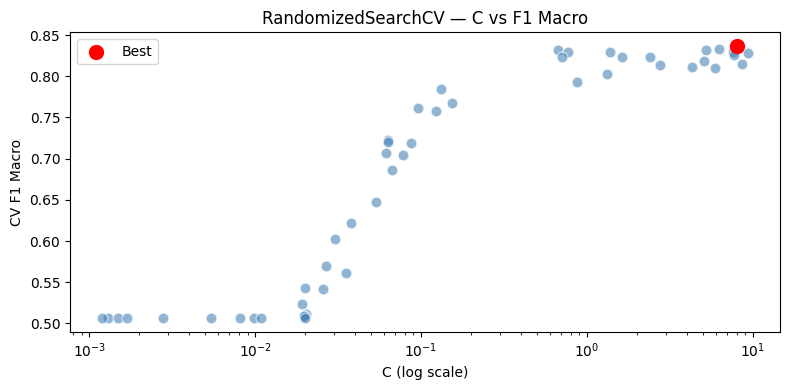

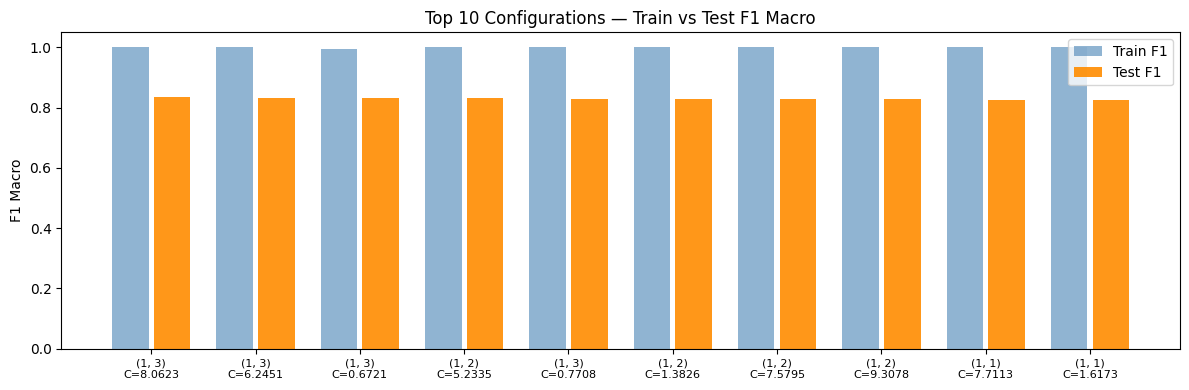

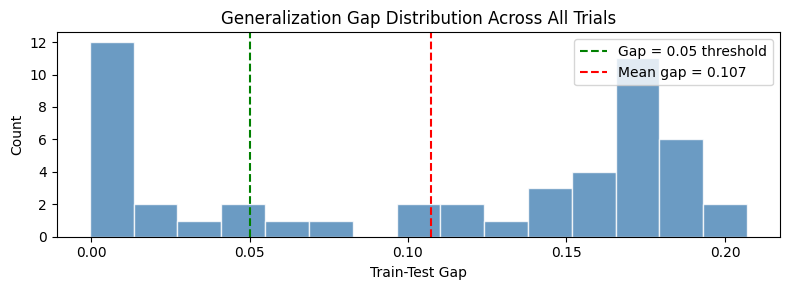


 Final Model Evaluation (best estimator, outer CV)
─────────────────────────────────────────────
  Train Accuracy : 1.0000
  Test Accuracy  : 0.8220 ± 0.0281
  F1 Macro       : 0.8207 ± 0.0274
  F1 Weighted    : 0.8197
  Gap            : 0.1780 → Still overfitting — try lower C


In [37]:


# ─────────────────────────────────────────
# Data
# ─────────────────────────────────────────
X_all, y_all = shuffle(X, y, random_state=42)

# ─────────────────────────────────────────
# Pipeline
# ─────────────────────────────────────────
preprocess = ColumnTransformer(transformers=[
    ("text", TfidfVectorizer(), "claim_sentence"),
    ("num",  "passthrough", ["has_number"])
])

pipeline = Pipeline([
    ("features", preprocess),
    ("svm",      LinearSVC(class_weight="balanced", random_state=42, max_iter=3000))
])

# ─────────────────────────────────────────
# Search Space
# ─────────────────────────────────────────
param_dist = {
    # SVM regularization — log-uniform samples more values near 0
    "svm__C"                         : loguniform(0.001, 10),

    # TF-IDF hyperparameters
    "features__text__ngram_range"    : [(1, 1), (1, 2), (1, 3)],
    "features__text__max_features"   : [5000, 10000, 20000, 30000],
    "features__text__sublinear_tf"   : [True, False],
    "features__text__max_df"         : [0.80, 0.85, 0.90, 0.95],
    "features__text__min_df"         : [1, 2, 3],
}

# ─────────────────────────────────────────
# RandomizedSearchCV
# ─────────────────────────────────────────
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator   = pipeline,
    param_distributions = param_dist,
    n_iter      = 50,           # number of random combinations to try
    cv          = cv_inner,
    scoring     = "f1_macro",   # optimise for F1 macro (better than accuracy for multi-class)
    refit       = True,         # refit best model on full data
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1,
    return_train_score = True
)

search.fit(X_all, y_all)

# ─────────────────────────────────────────
# Results
# ─────────────────────────────────────────
print("\n Best Parameters")
print("─" * 40)
for param, value in search.best_params_.items():
    print(f"  {param.split('__')[-1]:20s} : {value}")

print(f"\n  Best CV F1 Macro : {search.best_score_:.4f}")

# Full results dataframe
df_search = pd.DataFrame(search.cv_results_)
df_search = df_search[[
    "param_svm__C",
    "param_features__text__ngram_range",
    "param_features__text__max_features",
    "param_features__text__sublinear_tf",
    "param_features__text__max_df",
    "param_features__text__min_df",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

df_search.columns = [
    "C", "ngram", "max_features", "sublinear_tf",
    "max_df", "min_df",
    "Train F1", "Test F1", "Std", "Rank"
]
df_search["Gap"] = (df_search["Train F1"] - df_search["Test F1"]).round(4)
df_search["Train F1"] = df_search["Train F1"].round(4)
df_search["Test F1"]  = df_search["Test F1"].round(4)
df_search["C"]        = df_search["C"].round(4)

print("\n Top 10 Combinations")
print(df_search.head(10).to_string(index=False))

# ─────────────────────────────────────────
# Plot 1 — C vs F1 Macro (scatter)
# ─────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(df_search["C"], df_search["Test F1"],
            alpha=0.6, color="steelblue", edgecolors="white", s=60)
plt.scatter(search.best_params_["svm__C"],
            search.best_score_,
            color="red", s=100, zorder=5, label="Best")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV F1 Macro")
plt.title("RandomizedSearchCV — C vs F1 Macro")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 2 — Top 10 Combinations (bar chart)
# ─────────────────────────────────────────
top10 = df_search.head(10).copy()
top10["label"] = (top10["ngram"].astype(str) + "\nC=" +
                  top10["C"].astype(str))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(top10))
ax.bar(x - 0.2, top10["Train F1"], width=0.35,
       label="Train F1", alpha=0.6, color="steelblue")
ax.bar(x + 0.2, top10["Test F1"],  width=0.35,
       label="Test F1",  alpha=0.9, color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(top10["label"], fontsize=8)
ax.set_ylabel("F1 Macro")
ax.set_title("Top 10 Configurations — Train vs Test F1 Macro")
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 3 — Gap Distribution
# ─────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.hist(df_search["Gap"], bins=15, color="steelblue",
         edgecolor="white", alpha=0.8)
plt.axvline(0.05, color="green", linestyle="--", label="Gap = 0.05 threshold")
plt.axvline(df_search["Gap"].mean(), color="red",
            linestyle="--", label=f"Mean gap = {df_search['Gap'].mean():.3f}")
plt.xlabel("Train-Test Gap")
plt.ylabel("Count")
plt.title("Generalization Gap Distribution Across All Trials")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Final Evaluation on best model
# ─────────────────────────────────────────
from sklearn.model_selection import cross_validate

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

final_cv = cross_validate(
    search.best_estimator_,
    X_all, y_all,
    cv=cv_outer,
    scoring=["accuracy", "f1_macro", "f1_weighted"],
    return_train_score=True
)

gap = final_cv["train_accuracy"].mean() - final_cv["test_accuracy"].mean()

print("\n Final Model Evaluation (best estimator, outer CV)")
print("─" * 45)
print(f"  Train Accuracy : {final_cv['train_accuracy'].mean():.4f}")
print(f"  Test Accuracy  : {final_cv['test_accuracy'].mean():.4f} "
      f"± {final_cv['test_accuracy'].std():.4f}")
print(f"  F1 Macro       : {final_cv['test_f1_macro'].mean():.4f} "
      f"± {final_cv['test_f1_macro'].std():.4f}")
print(f"  F1 Weighted    : {final_cv['test_f1_weighted'].mean():.4f}")
print(f"  Gap            : {gap:.4f} →",
      "Good" if gap < 0.05 else
      "Acceptable" if gap < 0.08 else
      "Still overfitting — try lower C")

Classification Report
────────────────────────────────────────
              precision    recall  f1-score   support

        High       0.85      0.93      0.89        43
         Low       0.91      0.88      0.90        68
      Medium       0.81      0.78      0.80        55

    accuracy                           0.86       166
   macro avg       0.86      0.86      0.86       166
weighted avg       0.86      0.86      0.86       166



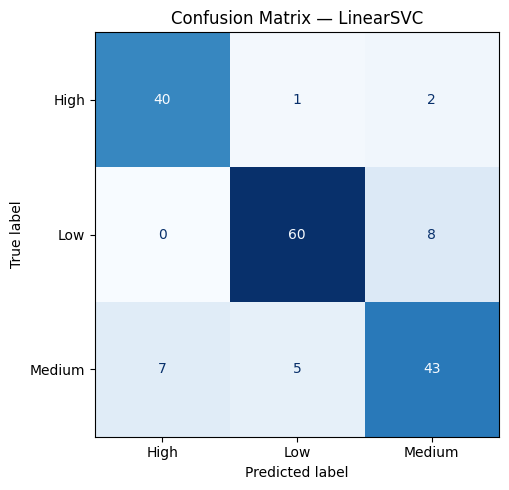

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# Shuffle + Split
# ─────────────────────────────────────────


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# ─────────────────────────────────────────
# Train
# ─────────────────────────────────────────
model.fit(X_train, y_train)
pred = model.predict(X_test)

# ─────────────────────────────────────────
# Classification Report
# ─────────────────────────────────────────
print("Classification Report")
print("─" * 40)
print(classification_report(y_test, pred, target_names=["High", "Low", "Medium"]))

# ─────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, pred, labels=["High", "Low", "Medium"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["High", "Low", "Medium"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — LinearSVC")
plt.tight_layout()
plt.show()

In [40]:
new_claim = "It is our ambition that all downstream sites are CO₂ neutral in 2030."

new_row = pd.DataFrame([{
    "claim_sentence": new_claim,
    "has_number": 1 
}])
prediction = model.predict(new_row)
print(f"\nNew claim prediction: {prediction[0]}")


New claim prediction: Medium


In [27]:
import re 
new_claims_list = [
    "By continuously improving our production processes using advanced techniques, we have succeeded in significantly reducing our carbon footprint since 1989.",
    "We spilled 10 barrels of oil in 2023.",
    "Carbon offsets were used to neutralize emissions from business travel."
]

def detect_has_number(text):
    return int(bool(re.search(r"\d", str(text))))

new_claims = pd.DataFrame({
    "claim_sentence": new_claims_list,
})

new_claims["has_number"] = new_claims["claim_sentence"].apply(detect_has_number)

print(new_claims)  # optional: see the dataframe
print(model.predict(new_claims))

                                      claim_sentence  has_number
0  By continuously improving our production proce...           1
1              We spilled 10 barrels of oil in 2023.           1
2  Carbon offsets were used to neutralize emissio...           0
['Medium' 'Low' 'High']


In [28]:
import joblib
joblib.dump(model, "greenwashing_tfidf_RF.pkl")

['greenwashing_tfidf_RF.pkl']

In [29]:
print(len("and taking steps to mitigate potential impacts and risks."))

57


Fitting 5 folds for each of 50 candidates, totalling 250 fits

 Best Parameters
────────────────────────────────────────
  tfidf__max_df                  : 0.95
  tfidf__max_features            : 1000
  tfidf__min_df                  : 2
  tfidf__ngram_range             : (1, 1)
  tfidf__sublinear_tf            : True
  rf__bootstrap                  : False
  rf__max_depth                  : 20
  rf__max_features               : 0.3
  rf__min_samples_leaf           : 4
  rf__min_samples_split          : 4
  rf__n_estimators               : 196

  Best CV F1 Macro : 0.8686

 Top 10 Combinations
 n_estimators max_depth  min_split  min_leaf max_feat  bootstrap  ngram  tfidf_features  Train F1  Test F1      Std  Rank    Gap
          196        20          4         4      0.3      False (1, 1)            1000    0.9667   0.8686 0.013815     1 0.0981
           84      None          5         3     sqrt      False (1, 2)            1000    0.9683   0.8686 0.014431     2 0.0997
          1

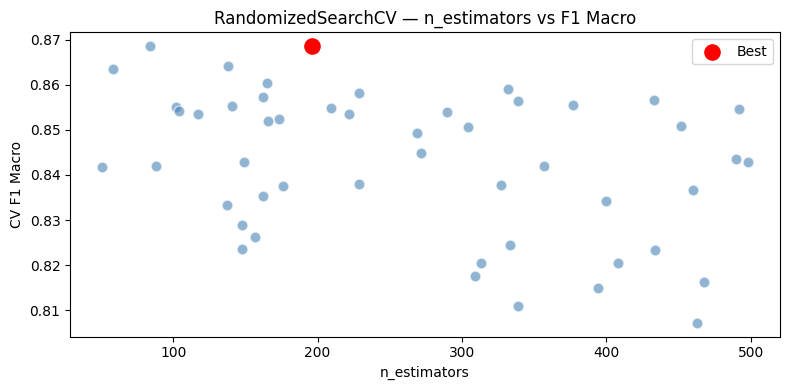

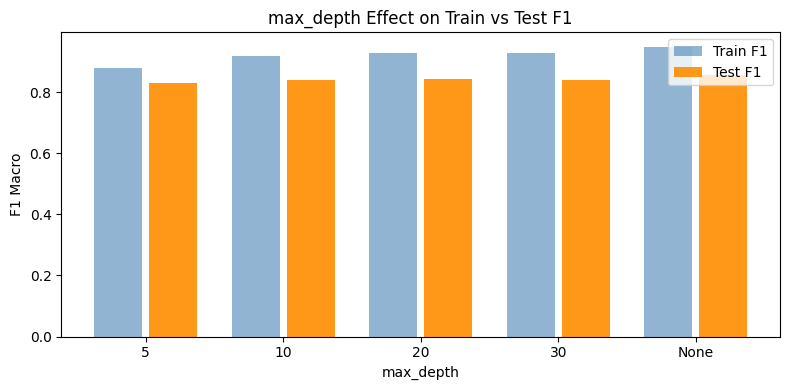

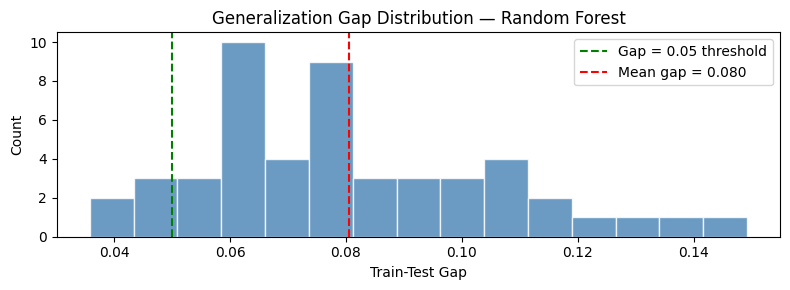

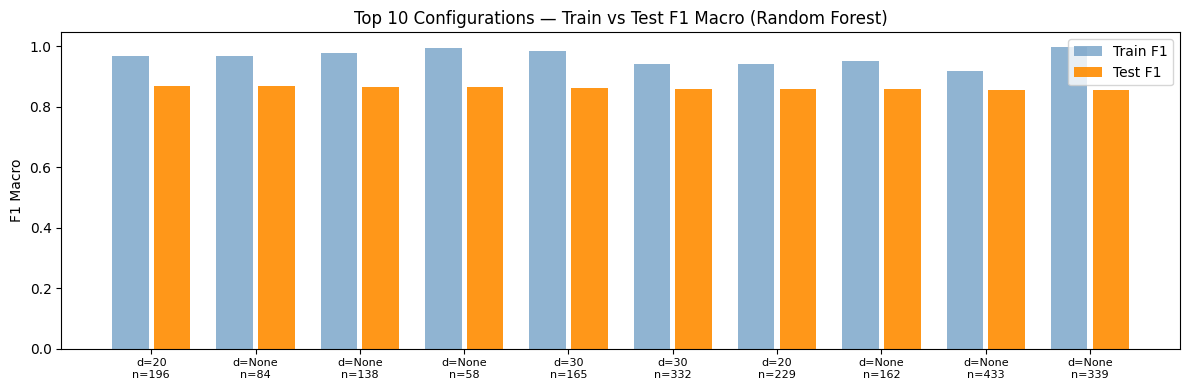


 Final Model Evaluation (best RF, outer CV)
─────────────────────────────────────────────
  Train Accuracy : 0.9664
  Test Accuracy  : 0.8535 ± 0.0213
  F1 Macro       : 0.8501 ± 0.0186
  F1 Weighted    : 0.8546
  Gap            : 0.1129 → Overfitting — try constraining max_depth or min_samples_leaf

 Model Comparison Summary
─────────────────────────────────────────────
  Model                 Test F1      Gap
  LinearSVC (tuned)      0.8286   0.1714
  Random Forest          0.8501   0.1129


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.utils import shuffle
from scipy.stats import randint
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# Data
# ─────────────────────────────────────────
X_all, y_all = shuffle(X, y, random_state=42)

# ─────────────────────────────────────────
# Pipeline
# ─────────────────────────────────────────
preprocess = ColumnTransformer(transformers=[
    ("text", TfidfVectorizer(), "claim_sentence"),
    ("num",  "passthrough", ["has_number"])
])

pipeline = Pipeline([
    ("features", preprocess),
    ("rf",       RandomForestClassifier(
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                ))
])

# ─────────────────────────────────────────
# Search Space
# ─────────────────────────────────────────
param_dist = {
    # Random Forest hyperparameters
    "rf__n_estimators"      : randint(50, 500),
    "rf__max_depth"         : [None, 5, 10, 20, 30],      # None = fully grown
    "rf__min_samples_split" : randint(2, 20),
    "rf__min_samples_leaf"  : randint(1, 10),
    "rf__max_features"      : ["sqrt", "log2", 0.3, 0.5], # features per split
    "rf__bootstrap"         : [True, False],

    # TF-IDF hyperparameters
    # Keep max_features low — RF on 20k features is extremely slow
    "features__text__ngram_range"  : [(1, 1), (1, 2)],
    "features__text__max_features" : [500, 1000, 2000, 3000],
    "features__text__sublinear_tf" : [True, False],
    "features__text__max_df"       : [0.85, 0.90, 0.95],
    "features__text__min_df"       : [1, 2],
}

# ─────────────────────────────────────────
# RandomizedSearchCV
# ─────────────────────────────────────────
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator           = pipeline,
    param_distributions = param_dist,
    n_iter              = 50,
    cv                  = cv_inner,
    scoring             = "f1_macro",
    refit               = True,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

search.fit(X_all, y_all)

# ─────────────────────────────────────────
# Results
# ─────────────────────────────────────────
print("\n Best Parameters")
print("─" * 40)
for param, value in search.best_params_.items():
    clean = param.replace("features__text__", "tfidf__").replace("rf__", "rf__")
    print(f"  {clean:30s} : {value}")

print(f"\n  Best CV F1 Macro : {search.best_score_:.4f}")

# Full results dataframe
df_search = pd.DataFrame(search.cv_results_)

df_search = df_search[[
    "param_rf__n_estimators",
    "param_rf__max_depth",
    "param_rf__min_samples_split",
    "param_rf__min_samples_leaf",
    "param_rf__max_features",
    "param_rf__bootstrap",
    "param_features__text__ngram_range",
    "param_features__text__max_features",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

df_search.columns = [
    "n_estimators", "max_depth", "min_split", "min_leaf",
    "max_feat", "bootstrap", "ngram", "tfidf_features",
    "Train F1", "Test F1", "Std", "Rank"
]

df_search["Gap"]     = (df_search["Train F1"] - df_search["Test F1"]).round(4)
df_search["Train F1"] = df_search["Train F1"].round(4)
df_search["Test F1"]  = df_search["Test F1"].round(4)

print("\n Top 10 Combinations")
print(df_search.head(10).to_string(index=False))

# ─────────────────────────────────────────
# Plot 1 — n_estimators vs F1 Macro
# ─────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(df_search["n_estimators"], df_search["Test F1"],
            alpha=0.6, color="steelblue", edgecolors="white", s=60)
plt.scatter(search.best_params_["rf__n_estimators"],
            search.best_score_,
            color="red", s=120, zorder=5, label="Best")
plt.xlabel("n_estimators")
plt.ylabel("CV F1 Macro")
plt.title("RandomizedSearchCV — n_estimators vs F1 Macro")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 2 — max_depth vs Train/Test F1
# ─────────────────────────────────────────
df_depth = df_search.copy()
df_depth["max_depth"] = df_depth["max_depth"].fillna("None")

depth_group = df_depth.groupby("max_depth")[["Train F1", "Test F1", "Gap"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(depth_group))
ax.bar(x - 0.2, depth_group["Train F1"], width=0.35,
       label="Train F1", alpha=0.6, color="steelblue")
ax.bar(x + 0.2, depth_group["Test F1"],  width=0.35,
       label="Test F1",  alpha=0.9, color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(depth_group["max_depth"])
ax.set_ylabel("F1 Macro")
ax.set_xlabel("max_depth")
ax.set_title("max_depth Effect on Train vs Test F1")
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 3 — Gap Distribution
# ─────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.hist(df_search["Gap"], bins=15, color="steelblue",
         edgecolor="white", alpha=0.8)
plt.axvline(0.05, color="green", linestyle="--",
            label="Gap = 0.05 threshold")
plt.axvline(df_search["Gap"].mean(), color="red", linestyle="--",
            label=f"Mean gap = {df_search['Gap'].mean():.3f}")
plt.xlabel("Train-Test Gap")
plt.ylabel("Count")
plt.title("Generalization Gap Distribution — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Plot 4 — Top 10 Configurations
# ─────────────────────────────────────────
top10 = df_search.head(10).copy()
top10["label"] = ("d=" + top10["max_depth"].astype(str) +
                  "\nn=" + top10["n_estimators"].astype(str))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(top10))
ax.bar(x - 0.2, top10["Train F1"], width=0.35,
       label="Train F1", alpha=0.6, color="steelblue")
ax.bar(x + 0.2, top10["Test F1"],  width=0.35,
       label="Test F1",  alpha=0.9, color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(top10["label"], fontsize=8)
ax.set_ylabel("F1 Macro")
ax.set_title("Top 10 Configurations — Train vs Test F1 Macro (Random Forest)")
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Final Evaluation — best model outer CV
# ─────────────────────────────────────────
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

final_cv = cross_validate(
    search.best_estimator_,
    X_all, y_all,
    cv=cv_outer,
    scoring=["accuracy", "f1_macro", "f1_weighted"],
    return_train_score=True
)

gap = final_cv["train_accuracy"].mean() - final_cv["test_accuracy"].mean()

print("\n Final Model Evaluation (best RF, outer CV)")
print("─" * 45)
print(f"  Train Accuracy : {final_cv['train_accuracy'].mean():.4f}")
print(f"  Test Accuracy  : {final_cv['test_accuracy'].mean():.4f} "
      f"± {final_cv['test_accuracy'].std():.4f}")
print(f"  F1 Macro       : {final_cv['test_f1_macro'].mean():.4f} "
      f"± {final_cv['test_f1_macro'].std():.4f}")
print(f"  F1 Weighted    : {final_cv['test_f1_weighted'].mean():.4f}")
print(f"  Gap            : {gap:.4f} →",
      "Good"       if gap < 0.05 else
      "Acceptable" if gap < 0.08 else
      "Overfitting — try constraining max_depth or min_samples_leaf")

# ─────────────────────────────────────────
# Compare LinearSVC vs Random Forest
# ─────────────────────────────────────────
print("\n Model Comparison Summary")
print("─" * 45)
print(f"  {'Model':<20} {'Test F1':>8} {'Gap':>8}")
print(f"  {'LinearSVC (tuned)':<20} {'0.8286':>8} {'0.1714':>8}")
print(f"  {'Random Forest':<20} {final_cv['test_f1_macro'].mean():>8.4f} {gap:>8.4f}")